In [2]:
# Task 1 : Exploratory Data Analysis(EDA)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")
#Loading diabetes dataset

In [4]:
print(df.info())
print(df.describe())
#Exploring information and statistics of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

In [5]:
print(df.isnull().sum())
#checking null values on dataset

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    print(f"{col} has {(df[col] == 0).sum()} zero values")
# Even if null does not exists in dataset still having zeroes is similar to having null and thus cannot give accurate predictions.

Glucose has 5 zero values
BloodPressure has 35 zero values
SkinThickness has 227 zero values
Insulin has 374 zero values
BMI has 11 zero values


In [7]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)
# Filling zeroes with median

In [8]:
for col in cols_with_zeros:
    print(f"{col} has {(df[col] == 0).sum()} zero values after replacement")

Glucose has 0 zero values after replacement
BloodPressure has 0 zero values after replacement
SkinThickness has 0 zero values after replacement
Insulin has 0 zero values after replacement
BMI has 0 zero values after replacement


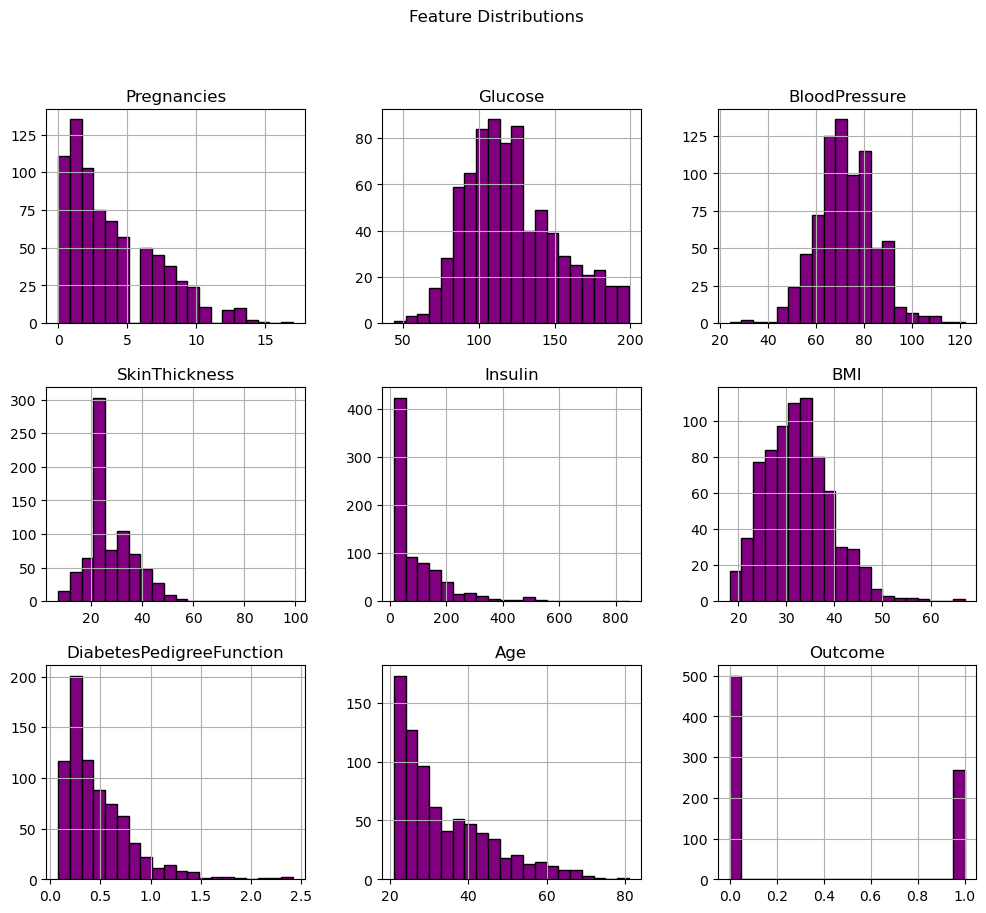

In [9]:
df.hist(figsize=(12, 10), bins=20, color='purple', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.show()
#Histograms to visualize the distribution and frequency of data values for each numerical feature.

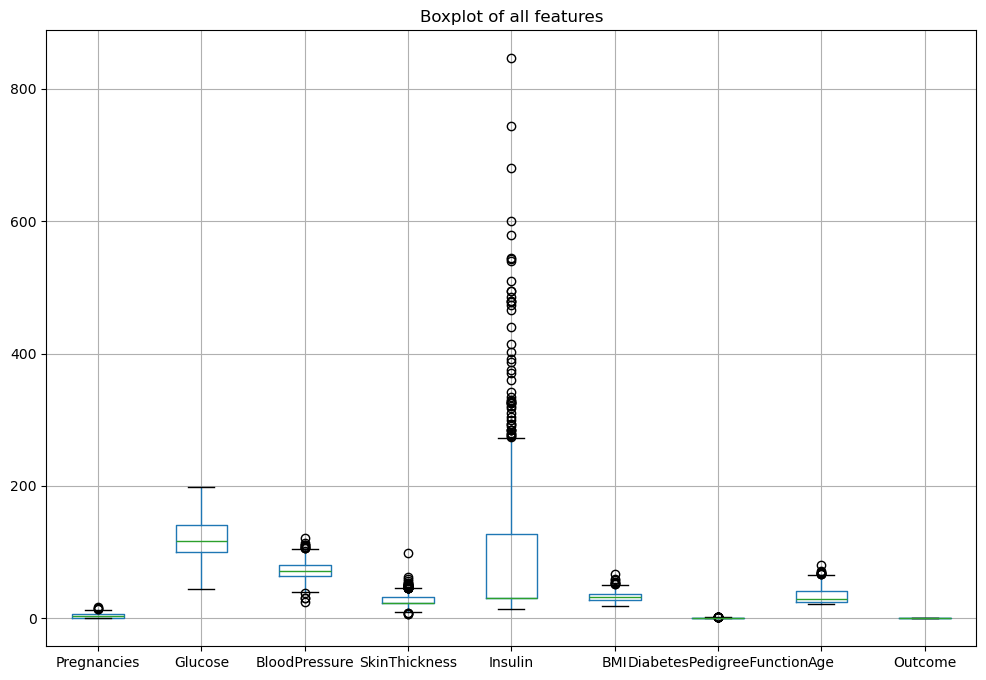

In [10]:
plt.figure(figsize=(12, 8))
df.boxplot()
plt.title('Boxplot of all features')
plt.show()
#Boxplots to visualize the spread of data and detect outliers in numerical features.

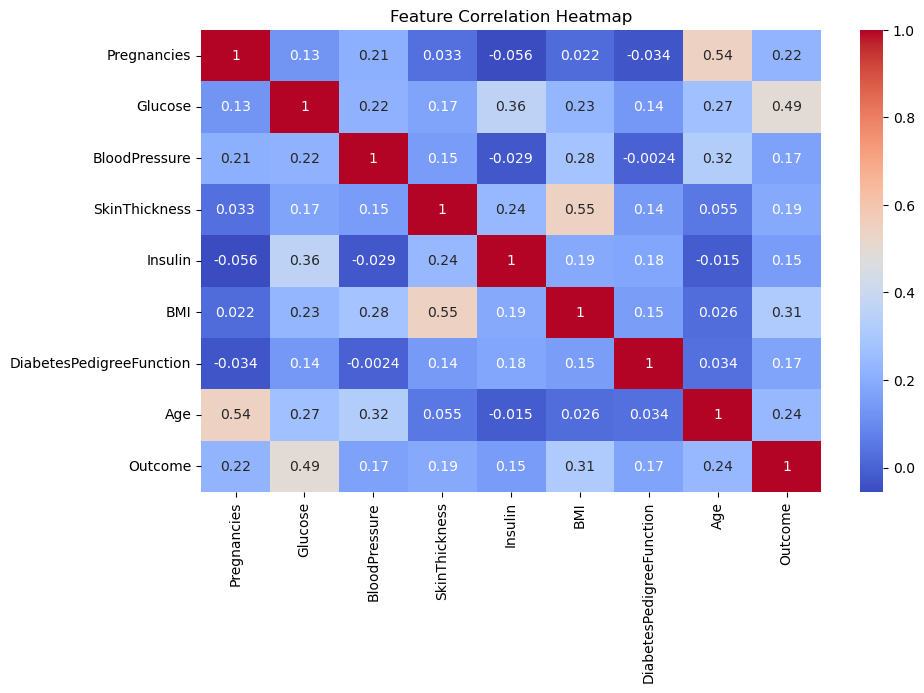

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
#Heatmap to visualize the correlation between numerical features in the dataset.

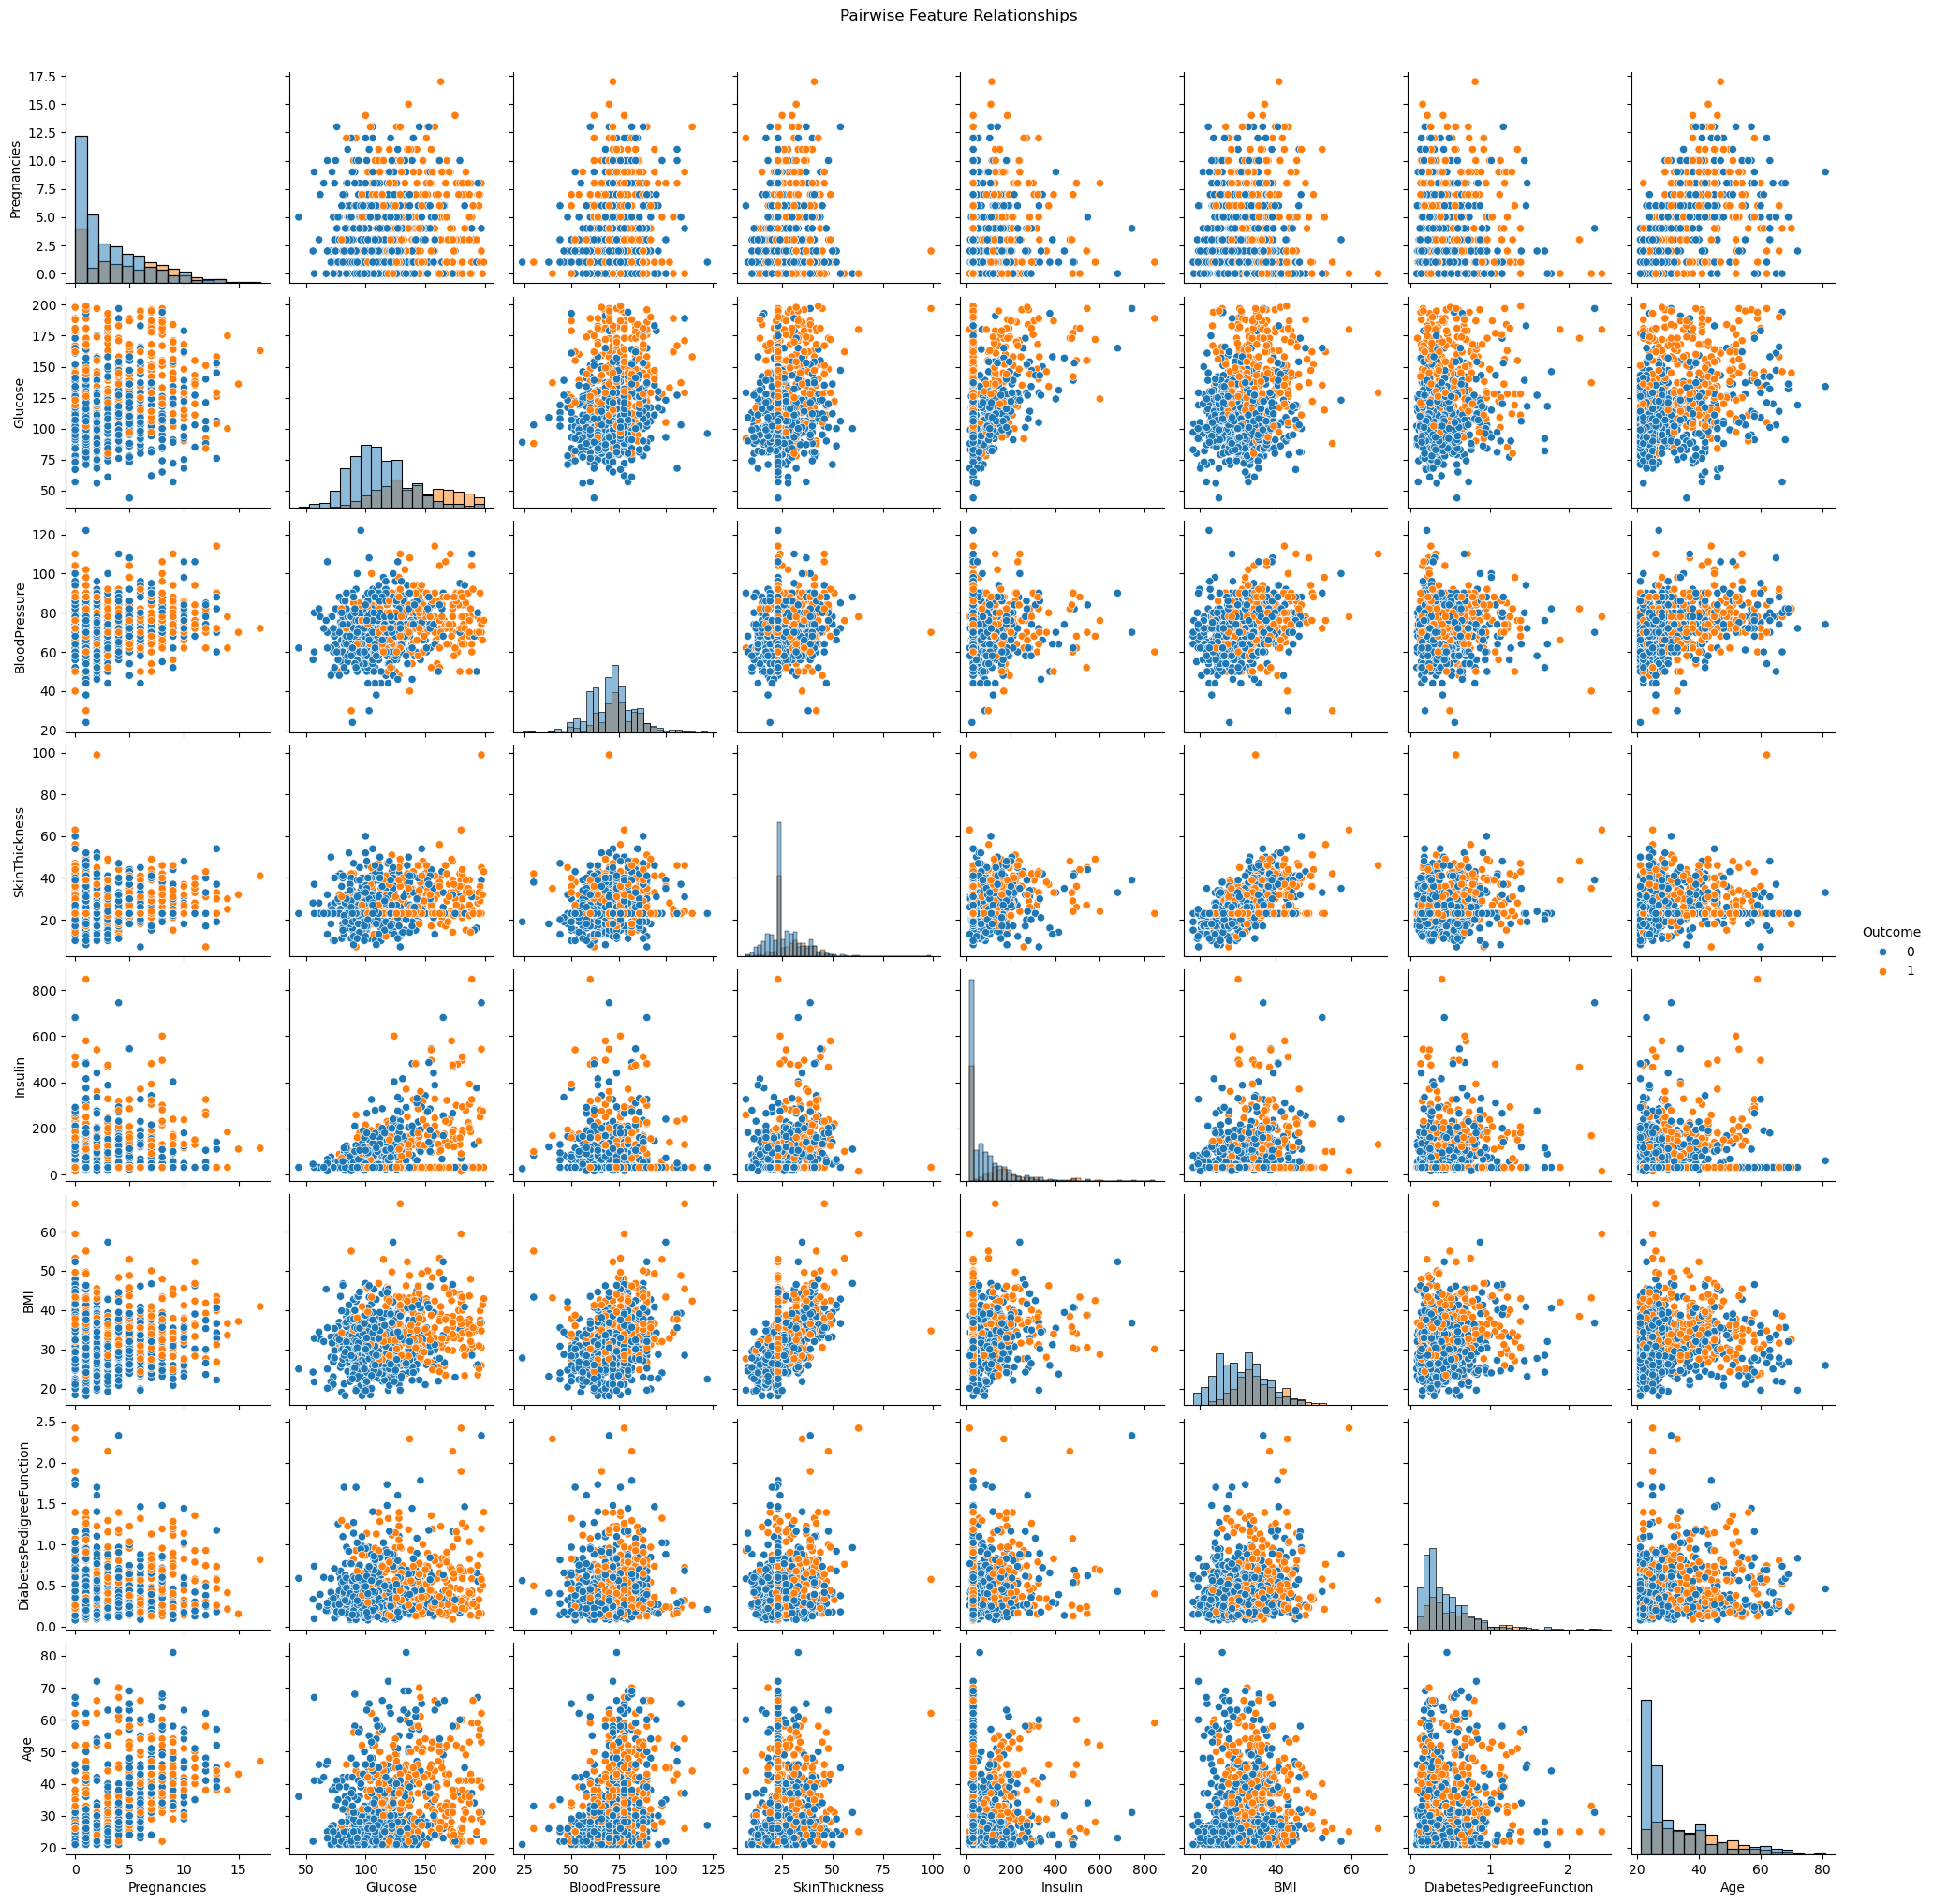

In [12]:
sns.pairplot(df, hue='Outcome', diag_kind='hist')
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()
#Pairplot to visualize relationships and patterns between multiple feature pairs, colored by the target variable.

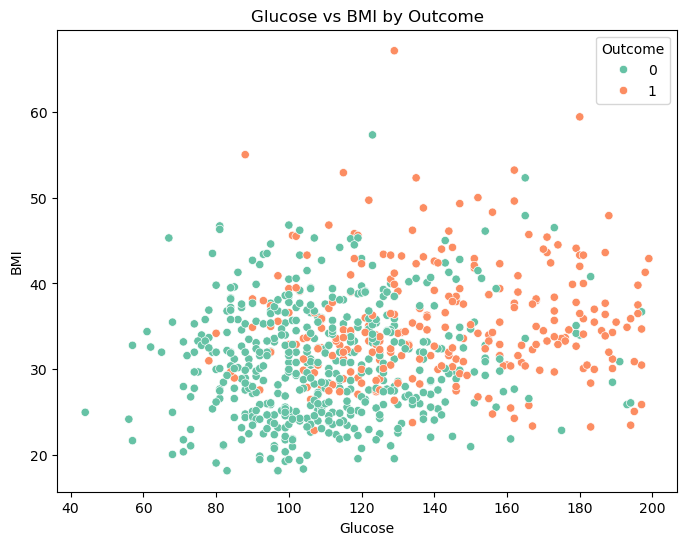

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', palette='Set2')
plt.title('Glucose vs BMI by Outcome')
plt.show()
#Scatterplot to visualize the relationship and correlation between two continuous variables.

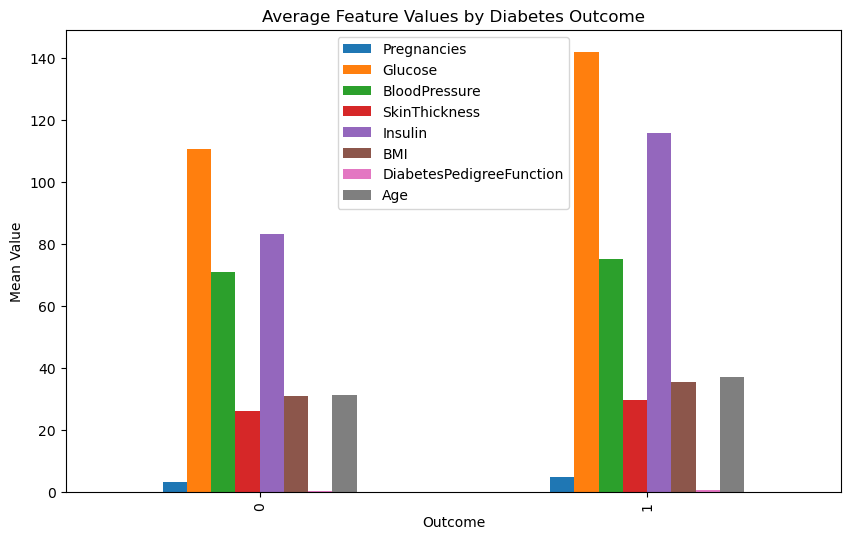

In [14]:
feature_means = df.groupby('Outcome').mean()
feature_means.plot(kind='bar', figsize=(10, 6))
plt.title('Average Feature Values by Diabetes Outcome')
plt.ylabel('Mean Value')
plt.show()

In [15]:
# Task 2 : Data Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
scaled_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])
# We scale numerical features using StandardScaler to normalize feature ranges.

In [17]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
# We separate features (X) and target variable (y) for model training.

In [18]:
# Task 3 : Building Predictive Models

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# We split the dataset into training and testing sets (80:20) to evaluate model performance on unseen data.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
# We use accuracy, precision, recall, and F1-score to evaluate classification performance.

In [22]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Performance:")
evaluate_model(y_test, y_pred_xgb)

XGBoost Performance:
Accuracy: 0.7467532467532467
Precision: 0.6530612244897959
Recall: 0.5925925925925926
F1 Score: 0.6213592233009708
Confusion Matrix:
 [[83 17]
 [22 32]]


In [26]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_child_samples=3,
    num_leaves=5,
    random_state=42
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
print("LightGBM Performance:")
evaluate_model(y_test, y_pred_lgb)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
LightGBM Performance:
Accuracy: 0.7467532467532467
Precision: 0.6530612244897959
Recall: 0.5925925925925926
F1 Score: 0.6213592233009708
Confusion Matrix:
 [[83 17]
 [22 32]]


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='f1')
cv_scores_lgb = cross_val_score(lgb_model, X, y, cv=5, scoring='f1')
print("XGBoost CV F1-score:", cv_scores_xgb.mean())
print("LightGBM CV F1-score:", cv_scores_lgb.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Info] Number of 

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


In [29]:
xgb_model_best = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb_model_best.fit(X_train, y_train)
y_pred_best = xgb_model_best.predict(X_test)

print("XGBoost (Tuned) Performance:")
evaluate_model(y_test, y_pred_best)

XGBoost (Tuned) Performance:
Accuracy: 0.7402597402597403
Precision: 0.625
Recall: 0.6481481481481481
F1 Score: 0.6363636363636364
Confusion Matrix:
 [[79 21]
 [19 35]]


In [34]:
param_grid_lgb = {
    'num_leaves': [7, 15, 31],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150]
}
lgb_model = lgb.LGBMClassifier(random_state=42)
grid_search_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search_lgb.fit(X_train, y_train)
best_params_lgb = grid_search_lgb.best_params_
print("Best Parameters for LightGBM:", best_params_lgb)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
Best Parameters for LightGBM: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 7}


In [33]:
lgb_model_best = lgb.LGBMClassifier(
    n_estimators=best_params_lgb['n_estimators'],
    learning_rate=best_params_lgb['learning_rate'],
    max_depth=best_params_lgb['max_depth'],
    num_leaves=best_params_lgb['num_leaves'],
    random_state=42
)
lgb_model_best.fit(X_train, y_train)
y_pred_lgb_best = lgb_model_best.predict(X_test)
print("LightGBM (Tuned) Performance:")
evaluate_model(y_test, y_pred_lgb_best)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
LightGBM (Tuned) Performance:
Accuracy: 0.7467532467532467
Precision: 0.6666666666666666
Recall: 0.5555555555555556
F1 Score: 0.6060606060606061
Confusion Matrix:
 [[85 15]
 [24 30]]


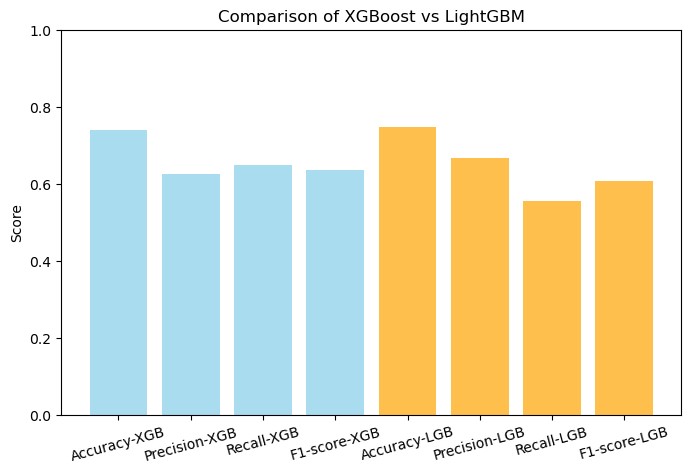

In [35]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
xgb_scores = [0.740, 0.625, 0.648, 0.636]
lgb_scores = [0.747, 0.667, 0.556, 0.606]

plt.figure(figsize=(8,5))
plt.bar([m + '-XGB' for m in metrics], xgb_scores, color='skyblue', alpha=0.7, label='XGBoost')
plt.bar([m + '-LGB' for m in metrics], lgb_scores, color='orange', alpha=0.7, label='LightGBM')
plt.ylabel('Score')
plt.title('Comparison of XGBoost vs LightGBM')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

In [36]:
#Both models perform similarly on default parameters. Recall is slightly lower than precision, meaning some diabetic cases are missed.
#Both models generalize similarly according to cross-validation.
#XGBoost: Better at identifying diabetic cases (higher recall), slightly lower precision.
#LightGBM: Higher overall accuracy and precision, but misses more diabetic cases (lower recall).
#Recall-focused - XGBoost (detect more positive cases)
#Precision/accuracy-focused - LightGBM

In [ ]:
# Conclusion :- 
# Both XGBoost and LightGBM are effective for diabetes prediction.
# Choice of model depends on whether recall (XGBoost) or precision/accuracy (LightGBM) is more critical in the application.
# Hyperparameter tuning and cross-validation slightly improve performance and provide more robust evaluation.